In [1]:
# Cell 1: Load, format and save GNN predictions as 5 separate fold CSVs

import pandas as pd
from pathlib import Path

# ── Paths — update these ──────────────────────────────────────────────────────
GNN_ROOT   = Path(r"C:\Users\Hp\OneDrive\Desktop\USYD\YEAR3S2\DATA3888\Project\DATA3888-Finance-21\GNN\prediction")   # folder containing fold_0, fold_1 etc
EXPORT_DIR = Path(r"E:\Optiver\GNN_pred")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
# ─────────────────────────────────────────────────────────────────────────────

for fold_idx in range(5):
    fold_path = GNN_ROOT / f"fold_{fold_idx}" / "gnn_predictions.csv"
    
    if not fold_path.exists():
        print(f"WARNING: {fold_path} not found — skipping")
        continue
    
    df = pd.read_csv(fold_path)
    
    # Keep only needed columns, rename to standard format, add fold
    df = df[["stock_id", "time_id", "true_rv", "pred_rv"]]\
          .rename(columns={
              "true_rv": "actual_rv",
              "pred_rv": "predicted_rv",
          })
    df.insert(2, "fold", fold_idx)
    df = df.sort_values(["stock_id", "time_id"]).reset_index(drop=True)
    
    out_path = EXPORT_DIR / f"gnn_fold_{fold_idx}_predictions.csv"
    df.to_csv(out_path, index=False)
    
    print(f"Fold {fold_idx}: {len(df):,} rows saved to {out_path.name}")
    print(df.head(3))
    print()

print("Cell 1 complete — GNN predictions saved to", EXPORT_DIR)

Fold 0: 85,786 rows saved to gnn_fold_0_predictions.csv
   stock_id  time_id  fold  actual_rv  predicted_rv
0         0        5     0   0.001467      0.001703
1         0      147     0   0.001014      0.001177
2         0      157     0   0.002212      0.002755

Fold 1: 85,790 rows saved to gnn_fold_1_predictions.csv
   stock_id  time_id  fold  actual_rv  predicted_rv
0         0       62     1   0.001154      0.000618
1         0      213     1   0.001287      0.001214
2         0      229     1   0.000183      0.000408

Fold 2: 85,789 rows saved to gnn_fold_2_predictions.csv
   stock_id  time_id  fold  actual_rv  predicted_rv
0         0       11     2   0.000896      0.000348
1         0       31     2   0.000987      0.000583
2         0       62     2   0.001154      0.000622

Fold 3: 85,787 rows saved to gnn_fold_3_predictions.csv
   stock_id  time_id  fold  actual_rv  predicted_rv
0         0       62     3   0.001154      0.000614
1         0      169     3   0.000721      0.

In [1]:
# Cell 0: Preprocess HAR-X — split single CSV into 5 fold CSVs
import pandas as pd
from pathlib import Path

HARX_DIR = Path(r"C:\Users\Hp\OneDrive\Desktop\USYD\YEAR3S2\DATA3888\Project\DATA3888-Finance-21\HAR-X")
HARX_EXPORT_DIR = HARX_DIR  # save fold CSVs into same folder

src = HARX_DIR / "har_rv_predictions.csv"   # ← update filename if different
df = pd.read_csv(src)

print(f"Loaded {len(df):,} rows | columns: {df.columns.tolist()}")
print(f"Folds present: {sorted(df['fold_id'].unique())}")

for fold_idx in range(5):
    fold_df = df[df["fold_id"] == fold_idx][["stock_id", "time_id", "fold_id",
                                              "target_rv_480_600", "predicted_rv_480_600"]]\
        .rename(columns={
            "fold_id":               "fold",
            "target_rv_480_600":     "actual_rv",
            "predicted_rv_480_600":  "predicted_rv",
        })\
        .sort_values(["stock_id", "time_id"])\
        .reset_index(drop=True)

    out_path = HARX_EXPORT_DIR / f"harx_fold{fold_idx}_predictions.csv"
    fold_df.to_csv(out_path, index=False)
    print(f"Fold {fold_idx}: {len(fold_df):,} rows → {out_path.name}")
    print(fold_df.head(3), "\n")

print("Cell 0 complete — HAR-X fold CSVs saved")

Loaded 428,932 rows | columns: ['fold_id', 'stock_id', 'time_id', 'target_rv_480_600', 'predicted_rv_480_600', 'absolute_error', 'percentage_error', 'naive_rv_360_480', 'naive_absolute_error', 'naive_percentage_error']
Folds present: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Fold 0: 85,786 rows → harx_fold0_predictions.csv
   stock_id  time_id  fold  actual_rv  predicted_rv
0         0        5     0   0.001467      0.001883
1         0      147     0   0.001014      0.001328
2         0      157     0   0.002212      0.003077 

Fold 1: 85,790 rows → harx_fold1_predictions.csv
   stock_id  time_id  fold  actual_rv  predicted_rv
0         0       62     1   0.001154      0.000749
1         0      213     1   0.001287      0.001296
2         0      229     1   0.000182      0.000562 

Fold 2: 85,789 rows → harx_fold2_predictions.csv
   stock_id  time_id  fold  actual_rv  predicted_rv
0         0       11     2   0.000896      0.000395
1         0       31     2   

In [2]:
# Cell 2: Format GARCH predictions in place — add fold column, rename columns

import pandas as pd
from pathlib import Path

# ── Path — update this ────────────────────────────────────────────────────────
GARCH_DIR = Path(r"C:\Users\Hp\OneDrive\Desktop\USYD\YEAR3S2\DATA3888\Project\DATA3888-Finance-21\GARCH")
# ─────────────────────────────────────────────────────────────────────────────

for fold_idx in range(5):
    file_path = GARCH_DIR / f"garch_predictions_fold{fold_idx}.csv"
    
    if not file_path.exists():
        print(f"WARNING: {file_path} not found — skipping")
        continue
    
    df = pd.read_csv(file_path)
    
    df = df.rename(columns={
        "true_rv": "actual_rv",
        "pred_rv": "predicted_rv",
    })
    df.insert(2, "fold", fold_idx)
    df = df.sort_values(["stock_id", "time_id"]).reset_index(drop=True)
    
    df.to_csv(file_path, index=False)
    
    print(f"Fold {fold_idx}: {len(df):,} rows updated in {file_path.name}")
    print(df.head(3))
    print()

print("Cell 2 complete — GARCH predictions updated in place")

ValueError: cannot insert fold, already exists

In [3]:
# Cell 2b: Fix GARCH stock_id format — strip 'stock_' prefix and convert to integer

import pandas as pd
from pathlib import Path

# ── Path ──────────────────────────────────────────────────────────────────────
GARCH_DIR = Path(r"C:\Users\Hp\OneDrive\Desktop\USYD\YEAR3S2\DATA3888\Project\DATA3888-Finance-21\GARCH")
# ─────────────────────────────────────────────────────────────────────────────

for fold_idx in range(5):
    file_path = GARCH_DIR / f"garch_predictions_fold{fold_idx}.csv"

    if not file_path.exists():
        print(f"WARNING: {file_path} not found — skipping")
        continue

    df = pd.read_csv(file_path)

    df["stock_id"] = df["stock_id"].astype(str)\
                                   .str.replace("stock_", "", regex=False)\
                                   .astype(int)

    df.to_csv(file_path, index=False)

    print(f"Fold {fold_idx}: stock_id fixed — sample: {df['stock_id'].head(3).tolist()}")

print("\nCell 2b complete — GARCH stock_id converted to integer")

Fold 0: stock_id fixed — sample: [0, 0, 0]
Fold 1: stock_id fixed — sample: [0, 0, 0]
Fold 2: stock_id fixed — sample: [0, 0, 0]
Fold 3: stock_id fixed — sample: [0, 0, 0]
Fold 4: stock_id fixed — sample: [0, 0, 0]

Cell 2b complete — GARCH stock_id converted to integer


In [2]:
# Cell 3 (updated): Diebold-Mariano tests — HAR-X replaces Base HAR
# Models: HAR-X, QLIKE-LGB, GNN, GARCH

import pandas as pd
import numpy as np
from scipy import stats
from pathlib import Path
import itertools

# ── Paths ──────────────────────────────────────────────────────────────────────
HARX_DIR  = Path(r"C:\Users\Hp\OneDrive\Desktop\USYD\YEAR3S2\DATA3888\Project\DATA3888-Finance-21\HAR-X")
QLIKE_DIR = Path(r"C:\Users\Hp\OneDrive\Desktop\USYD\YEAR3S2\DATA3888\Project\DATA3888-Finance-21\HAR+LightGBM(QLIKE)")
GNN_DIR   = Path(r"E:\Optiver\GNN_pred")
GARCH_DIR = Path(r"C:\Users\Hp\OneDrive\Desktop\USYD\YEAR3S2\DATA3888\Project\DATA3888-Finance-21\GARCH")
EVAL_DIR  = Path(r"E:\Optiver\outputs\evaluation")
EVAL_DIR.mkdir(parents=True, exist_ok=True)

EPS = 1e-10

# ── Loader ─────────────────────────────────────────────────────────────────────
def load_model_folds(fold_dir, filename_fn):
    frames = []
    for fold_idx in range(5):
        path = fold_dir / filename_fn(fold_idx)
        if not path.exists():
            print(f"WARNING: {path} not found — skipping")
            continue
        frames.append(pd.read_csv(path))
    if not frames:
        raise ValueError(f"No files found in {fold_dir}")
    df = pd.concat(frames, ignore_index=True)
    df["stock_id"] = df["stock_id"].astype(int)
    df["time_id"]  = df["time_id"].astype(int)
    df["fold"]     = df["fold"].astype(int)
    return df

print("Loading all models...")
harx_df  = load_model_folds(HARX_DIR,  lambda f: f"harx_fold{f}_predictions.csv")
qlike_df = load_model_folds(QLIKE_DIR, lambda f: f"qlike_lgb_fold{f}_predictions.csv")
gnn_df   = load_model_folds(GNN_DIR,   lambda f: f"gnn_fold_{f}_predictions.csv")
garch_df = load_model_folds(GARCH_DIR, lambda f: f"garch_predictions_fold{f}.csv")

for name, df in [("HAR-X", harx_df), ("QLIKE-LGB", qlike_df),
                 ("GNN", gnn_df), ("GARCH", garch_df)]:
    print(f"  {name:<12} {len(df):,} rows | folds: {sorted(df['fold'].unique())}")

# ── Align ──────────────────────────────────────────────────────────────────────
print("\nAligning all models...")
base = harx_df[["stock_id", "time_id", "fold", "actual_rv"]].copy()
for name, df in [("HAR-X", harx_df), ("QLIKE-LGB", qlike_df),
                 ("GNN", gnn_df), ("GARCH", garch_df)]:
    base = base.merge(
        df[["stock_id", "time_id", "fold", "predicted_rv"]].rename(
            columns={"predicted_rv": f"pred_{name}"}),
        on=["stock_id", "time_id", "fold"],
        how="inner",
    )
print(f"Aligned rows: {len(base):,}")

# ── Actual RV consistency check ────────────────────────────────────────────────
print("\nActual RV consistency check:")
for name, df in [("QLIKE-LGB", qlike_df), ("GNN", gnn_df), ("GARCH", garch_df)]:
    merged = base.merge(
        df[["stock_id", "time_id", "fold", "actual_rv"]].rename(
            columns={"actual_rv": f"actual_{name}"}),
        on=["stock_id", "time_id", "fold"], how="inner",
    )
    max_diff = (merged["actual_rv"] - merged[f"actual_{name}"]).abs().max()
    status = "OK" if max_diff < 1e-6 else "WARNING — possible mismatch"
    print(f"  {name:<12} max diff: {max_diff:.2e}  {status}")

actual      = base["actual_rv"].values
model_names = ["HAR-X", "QLIKE-LGB", "GNN", "GARCH"]

# ── Loss functions ─────────────────────────────────────────────────────────────
def rmspe_loss(y_true, y_pred):
    y_true = np.maximum(y_true, EPS); y_pred = np.maximum(y_pred, EPS)
    return ((y_true - y_pred) / y_true) ** 2

def qlike_loss(y_true, y_pred):
    y_true = np.maximum(y_true, EPS); y_pred = np.maximum(y_pred, EPS)
    return y_true / y_pred - np.log(y_true / y_pred) - 1

# ── Newey-West HAC variance ────────────────────────────────────────────────────
def newey_west_var(d, h):
    n      = len(d)
    gamma0 = np.var(d, ddof=1)
    gamma  = sum(
        [(1 - k / (h + 1)) * np.cov(d[k:], d[:-k])[0, 1]
         for k in range(1, h + 1)]
    )
    return (gamma0 + 2 * gamma) / n

# ── DM test ────────────────────────────────────────────────────────────────────
def diebold_mariano(y_true, pred1, pred2, loss_fn):
    """Positive DM stat = model 2 significantly better than model 1."""
    d      = loss_fn(y_true, pred1) - loss_fn(y_true, pred2)
    n      = len(d)
    h      = int(n ** (1 / 3))
    var_d  = newey_west_var(d, h)
    dm_stat = d.mean() / np.sqrt(max(var_d, EPS))
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return float(dm_stat), float(p_value)

def sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

# ── Pooled metrics ─────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"Pooled OOF Metrics — All Models")
print(f"{'='*60}")
print(f"  {'Model':<12} {'RMSPE':>10} {'QLIKE':>10}")
print(f"  {'='*35}")
for name in model_names:
    pred = base[f"pred_{name}"].values
    r    = float(np.sqrt(np.mean(rmspe_loss(actual, pred))))
    q    = float(np.mean(qlike_loss(actual, pred)))
    print(f"  {name:<12} {r:>10.6f} {q:>10.6f}")

# ── DM tests ───────────────────────────────────────────────────────────────────
results = []
for metric_name, loss_fn in [("RMSPE", rmspe_loss), ("QLIKE", qlike_loss)]:
    print(f"\n{'='*65}")
    print(f"Diebold-Mariano Tests — {metric_name}")
    print(f"Positive DM stat = model 2 significantly better")
    print(f"{'='*65}")
    print(f"  {'Model 1':<12} {'Model 2':<12} {'DM Stat':>10} {'p-value':>10} {'Sig':>5}")
    print(f"  {'-'*52}")
    for m1, m2 in itertools.combinations(model_names, 2):
        pred1 = base[f"pred_{m1}"].values
        pred2 = base[f"pred_{m2}"].values
        dm, p = diebold_mariano(actual, pred1, pred2, loss_fn)
        sig   = sig_stars(p)
        print(f"  {m1:<12} {m2:<12} {dm:>10.4f} {p:>10.4f} {sig:>5}")
        results.append({"metric": metric_name, "model_1": m1, "model_2": m2,
                         "dm_stat": dm, "p_value": p, "sig": sig})

# ── Per-fold breakdown ─────────────────────────────────────────────────────────
fold_qlike_metrics = {name: [] for name in model_names}
fold_rmspe_metrics = {name: [] for name in model_names}

for label, fold_data, loss_fn in [
    ("RMSPE", fold_rmspe_metrics, rmspe_loss),
    ("QLIKE",  fold_qlike_metrics, qlike_loss),
]:
    print(f"\n{'='*65}")
    print(f"Per-fold {label} breakdown")
    print(f"{'='*65}")
    print(f"  {'Fold':<6}", end="")
    for name in model_names:
        print(f"  {name:>12}", end="")
    print()
    for f in range(5):
        mask = base["fold"].values == f
        print(f"  {f:<6}", end="")
        for name in model_names:
            pred = base[f"pred_{name}"].values
            val  = (float(np.sqrt(np.mean(loss_fn(actual[mask], pred[mask]))))
                    if label == "RMSPE"
                    else float(np.mean(loss_fn(actual[mask], pred[mask]))))
            fold_data[name].append(val)
            print(f"  {val:>12.6f}", end="")
        print()

print(f"\nFold metrics stored as fold_qlike_metrics and fold_rmspe_metrics for Cell 5")

# ── Save ───────────────────────────────────────────────────────────────────────
dm_df = pd.DataFrame(results)
dm_df.to_csv(EVAL_DIR / "dm_tests_all_models.csv", index=False)
print(f"\nSaved: {EVAL_DIR / 'dm_tests_all_models.csv'}")
print("Cell 3 complete")

Loading all models...
  HAR-X        428,932 rows | folds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  QLIKE-LGB    428,932 rows | folds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  GNN          428,932 rows | folds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  GARCH        428,932 rows | folds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Aligning all models...
Aligned rows: 428,932

Actual RV consistency check:
  QLIKE-LGB    max diff: 7.87e-03  WARNING — possible mismatch
  GNN          max diff: 3.10e-07  OK
  GARCH        max diff: 5.00e-10  OK

Pooled OOF Metrics — All Models
  Model             RMSPE      QLIKE
  HAR-X          0.541578   0.051122
  QLIKE-LGB      0.550090   0.044977
  GNN            0.412102   0.072461
  GARCH          1.332292   0.056413

Diebold-Mariano Tests — RMSPE
Positive DM stat = model 2 significantly better
  Model 1      Model 2         DM Stat    p-value   Si

In [3]:
# Cell CHECK: Validate row counts across all original prediction files

import pandas as pd
from pathlib import Path

# ── Paths — original files ────────────────────────────────────────────────────
HARX_DIR  = Path(r"C:\Users\Hp\OneDrive\Desktop\USYD\YEAR3S2\DATA3888\Project\DATA3888-Finance-21\HAR-X")
QLIKE_DIR = Path(r"C:\Users\Hp\OneDrive\Desktop\USYD\YEAR3S2\DATA3888\Project\DATA3888-Finance-21\HAR+LightGBM(QLIKE)")
GNN_ROOT  = Path(r"C:\Users\Hp\OneDrive\Desktop\USYD\YEAR3S2\DATA3888\Project\DATA3888-Finance-21\GNN\prediction")     # folder containing fold_0, fold_1 etc
GARCH_DIR = Path(r"C:\Users\Hp\OneDrive\Desktop\USYD\YEAR3S2\DATA3888\Project\DATA3888-Finance-21\GARCH")
EPS       = 1e-10
# ─────────────────────────────────────────────────────────────────────────────

print(f"{'='*60}")
print(f"Row count validation — original prediction files")
print(f"{'='*60}")

# HAR-X — single file, split by fold_id
print(f"\nHAR-X:")
harx_src = HARX_DIR / "har_rv_predictions.csv"   # ← update if filename differs
harx_df  = pd.read_csv(harx_src)
harx_total = 0
for fold_idx in range(5):
    n = len(harx_df[harx_df["fold_id"] == fold_idx])
    harx_total += n
    print(f"  fold_{fold_idx}: {n:,} rows")
print(f"  Total: {harx_total:,}")

# QLIKE-LGB
print(f"\nQLIKE-LGB:")
qlike_total = 0
for fold_idx in range(5):
    path  = QLIKE_DIR / f"qlike_lgb_fold{fold_idx}_predictions.csv"
    n     = len(pd.read_csv(path))
    qlike_total += n
    print(f"  fold_{fold_idx}: {n:,} rows")
print(f"  Total: {qlike_total:,}")

# GNN — reads from original fold folders
print(f"\nGNN:")
gnn_total = 0
for fold_idx in range(5):
    path  = GNN_ROOT / f"fold_{fold_idx}" / "gnn_predictions.csv"
    n     = len(pd.read_csv(path))
    gnn_total += n
    print(f"  fold_{fold_idx}: {n:,} rows")
print(f"  Total: {gnn_total:,}")

# GARCH
print(f"\nGARCH:")
garch_total = 0
for fold_idx in range(5):
    path  = GARCH_DIR / f"garch_predictions_fold{fold_idx}.csv"
    n     = len(pd.read_csv(path))
    garch_total += n
    print(f"  fold_{fold_idx}: {n:,} rows")
print(f"  Total: {garch_total:,}")

# Summary
print(f"\n{'='*60}")
print(f"Summary")
print(f"{'='*60}")
print(f"  {'Model':<12} {'Total rows':>12} {'vs HAR':>10}")
print(f"  {'='*36}")
for name, total in [("HAR-X", harx_total), ("QLIKE-LGB", qlike_total),
                    ("GNN", gnn_total), ("GARCH", garch_total)]:
    diff = total - harx_total
    print(f"  {name:<12} {total:>12,} {diff:>+10,}")

print(f"\nCell 4 complete")

Row count validation — original prediction files

HAR-X:
  fold_0: 85,786 rows
  fold_1: 85,790 rows
  fold_2: 85,789 rows
  fold_3: 85,787 rows
  fold_4: 85,780 rows
  Total: 428,932

QLIKE-LGB:
  fold_0: 85,786 rows
  fold_1: 85,790 rows
  fold_2: 85,789 rows
  fold_3: 85,787 rows
  fold_4: 85,780 rows
  Total: 428,932

GNN:
  fold_0: 85,786 rows
  fold_1: 85,790 rows
  fold_2: 85,789 rows
  fold_3: 85,787 rows
  fold_4: 85,780 rows
  Total: 428,932

GARCH:
  fold_0: 85,786 rows
  fold_1: 85,790 rows
  fold_2: 85,789 rows
  fold_3: 85,787 rows
  fold_4: 85,780 rows
  Total: 428,932

Summary
  Model          Total rows     vs HAR
  HAR-X             428,932         +0
  QLIKE-LGB         428,932         +0
  GNN               428,932         +0
  GARCH             428,932         +0

Cell 4 complete


In [4]:
# Cell 4: Multiple testing correction — Benjamini-Hochberg FDR
from statsmodels.stats.multitest import multipletests
import pandas as pd
from pathlib import Path

EVAL_DIR = Path(r"E:\Optiver\outputs\evaluation")

dm_df = pd.read_csv(EVAL_DIR / "dm_tests_all_models.csv")

print(f"{'='*75}")
print(f"Multiple Testing Correction — Benjamini-Hochberg FDR")
print(f"{'='*75}")
print(f"  {'Metric':<8} {'Model 1':<12} {'Model 2':<12} {'DM Stat':>10} {'p-value':>10} {'p-corrected':>12} {'Sig':>5}")
print(f"  {'-'*70}")

for metric in ["RMSPE", "QLIKE"]:
    mask               = dm_df["metric"] == metric
    pvals              = dm_df.loc[mask, "p_value"].values
    rejected, pvals_corrected, _, _ = multipletests(pvals, method="fdr_bh")
    dm_df.loc[mask, "p_value_corrected"] = pvals_corrected
    dm_df.loc[mask, "rejected_corrected"] = rejected

    for _, row in dm_df[mask].iterrows():
        sig = "***" if row["p_value_corrected"] < 0.001 else \
              "**"  if row["p_value_corrected"] < 0.01  else \
              "*"   if row["p_value_corrected"] < 0.05  else ""
        print(f"  {metric:<8} {row['model_1']:<12} {row['model_2']:<12} "
              f"{row['dm_stat']:>10.4f} {row['p_value']:>10.4f} "
              f"{row['p_value_corrected']:>12.6f} {sig:>5}")

dm_df.to_csv(EVAL_DIR / "dm_tests_all_models_corrected.csv", index=False)
print(f"\nSaved: {EVAL_DIR / 'dm_tests_all_models_corrected.csv'}")
print("Cell 4 complete")

Multiple Testing Correction — Benjamini-Hochberg FDR
  Metric   Model 1      Model 2         DM Stat    p-value  p-corrected   Sig
  ----------------------------------------------------------------------
  RMSPE    HAR-X        QLIKE-LGB       -2.6314     0.0085     0.017007     *
  RMSPE    HAR-X        GNN             14.9232     0.0000     0.000000   ***
  RMSPE    HAR-X        GARCH           -2.0651     0.0389     0.040150     *
  RMSPE    QLIKE-LGB    GNN             15.5254     0.0000     0.000000   ***
  RMSPE    QLIKE-LGB    GARCH           -2.0522     0.0402     0.040150     *
  RMSPE    GNN          GARCH           -2.2359     0.0254     0.038041     *
  QLIKE    HAR-X        QLIKE-LGB       33.9120     0.0000     0.000000   ***
  QLIKE    HAR-X        GNN            -36.8620     0.0000     0.000000   ***
  QLIKE    HAR-X        GARCH          -28.2395     0.0000     0.000000   ***
  QLIKE    QLIKE-LGB    GNN            -42.9223     0.0000     0.000000   ***
  QLIKE    QLIKE


95% Confidence Intervals — QLIKE
  Pooled OOF: computed on all observations concatenated
  CI Mean:    mean of 5 fold-level metrics
  Model          Pooled OOF    CI Mean     CI Lower     CI Upper
  HAR-X            0.051122   0.051122     0.050013     0.052232
  QLIKE-LGB        0.044977   0.044977     0.044201     0.045753
  GNN              0.072461   0.072461     0.070751     0.074171
  GARCH            0.056413   0.056413     0.055668     0.057158

95% Confidence Intervals — RMSPE
  Pooled OOF: computed on all observations concatenated
  CI Mean:    mean of 5 fold-level metrics
  Model          Pooled OOF    CI Mean     CI Lower     CI Upper
  HAR-X            0.541578   0.540496     0.492991     0.588002
  QLIKE-LGB        0.550090   0.549071     0.502596     0.595546
  GNN              0.412102   0.411254     0.374560     0.447947
  GARCH            1.332292   1.263701     0.677943     1.849459


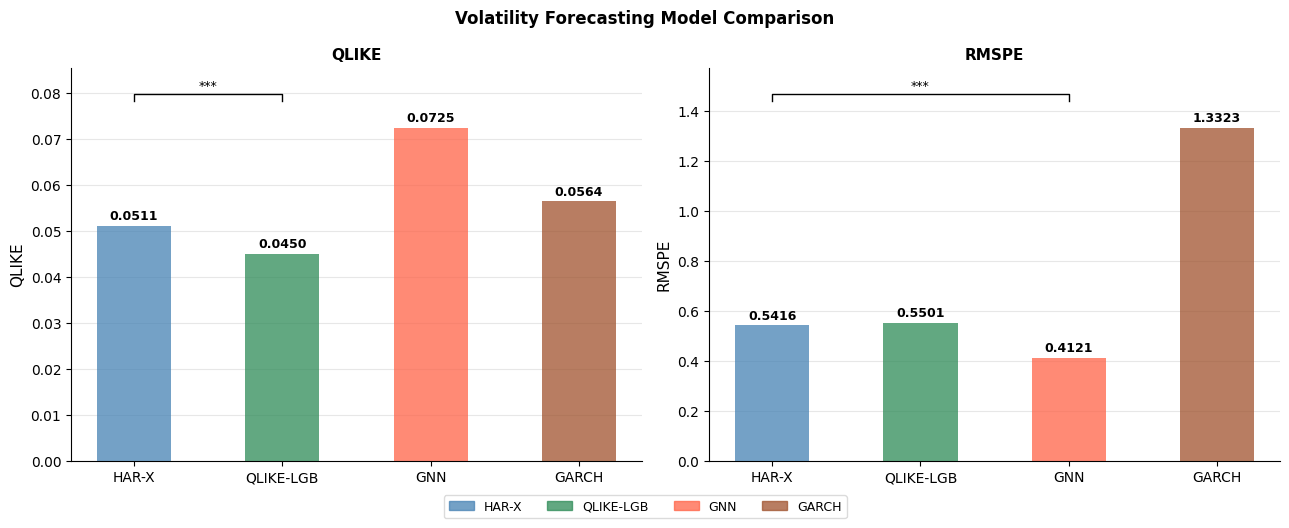

Saved: E:\Optiver\outputs\evaluation\model_comparison_pooled_oof.png


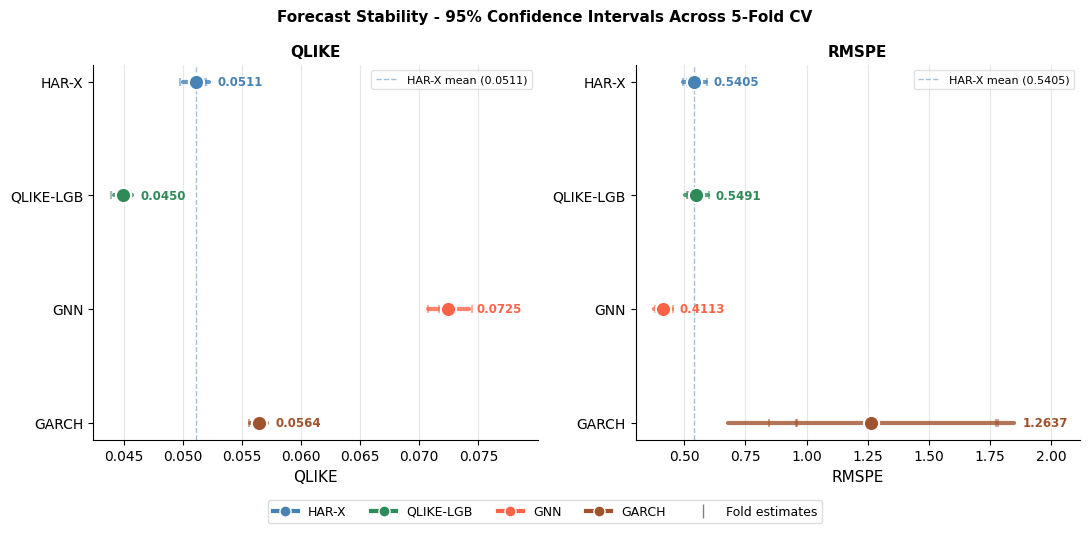

Saved: E:\Optiver\outputs\evaluation\model_comparison_forest.png
Cell 5 complete


In [18]:
# Cell 5: Two figures for report
#   1. Bar chart — pooled OOF RMSPE and QLIKE (point estimates)
#   2. Forest plot — 95% CI across folds (uncertainty)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from scipy import stats
from pathlib import Path

EVAL_DIR    = Path(r"E:\Optiver\outputs\evaluation")
model_names = ["HAR-X", "QLIKE-LGB", "GNN", "GARCH"]
colors      = ["steelblue", "seagreen", "tomato", "sienna"]
EPS         = 1e-10
plt.style.use("default")
# ── CI helper ─────────────────────────────────────────────────────────────────
def compute_ci(fold_values, confidence=0.95):
    arr  = np.array(fold_values)
    mean = arr.mean()
    se   = stats.sem(arr)
    ci   = stats.t.interval(confidence, df=len(arr) - 1, loc=mean, scale=se)
    return mean, ci[0], ci[1]

# ── Loss functions ─────────────────────────────────────────────────────────────
def rmspe_loss(y_true, y_pred):
    y_true = np.maximum(y_true, EPS)
    y_pred = np.maximum(y_pred, EPS)
    return ((y_true - y_pred) / y_true) ** 2

def qlike_loss(y_true, y_pred):
    y_true = np.maximum(y_true, EPS)
    y_pred = np.maximum(y_pred, EPS)
    return y_true / y_pred - np.log(y_true / y_pred) - 1

# ── Pooled OOF metrics ────────────────────────────────────────────────────────
actual       = base["actual_rv"].values
pooled_rmspe = {}
pooled_qlike = {}
for name in model_names:
    pred = base[f"pred_{name}"].values
    pooled_rmspe[name] = float(np.sqrt(np.mean(rmspe_loss(actual, pred))))
    pooled_qlike[name] = float(np.mean(qlike_loss(actual, pred)))

# ── Print CI tables ───────────────────────────────────────────────────────────
for label, fold_data in [("QLIKE", fold_qlike_metrics), ("RMSPE", fold_rmspe_metrics)]:
    print(f"\n{'='*70}")
    print(f"95% Confidence Intervals — {label}")
    print(f"  Pooled OOF: computed on all observations concatenated")
    print(f"  CI Mean:    mean of 5 fold-level metrics")
    print(f"{'='*70}")
    print(f"  {'Model':<12} {'Pooled OOF':>12} {'CI Mean':>10} {'CI Lower':>12} {'CI Upper':>12}")
    print(f"  {'='*60}")
    pooled = pooled_qlike if label == "QLIKE" else pooled_rmspe
    for name in model_names:
        mean, lo, hi = compute_ci(fold_data[name])
        print(f"  {name:<12} {pooled[name]:>12.6f} {mean:>10.6f} {lo:>12.6f} {hi:>12.6f}")
        
# ── Load BH-corrected DM results ──────────────────────────────────────────────
dm_df = pd.read_csv(EVAL_DIR / "dm_tests_all_models_corrected.csv")

def get_sig(metric, m1, m2):
    row = dm_df[
        (dm_df["metric"] == metric) &
        (((dm_df["model_1"] == m1) & (dm_df["model_2"] == m2)) |
         ((dm_df["model_1"] == m2) & (dm_df["model_2"] == m1)))
    ]
    if row.empty:
        return ""
    p = row["p_value_corrected"].values[0]
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1: Bar chart — pooled OOF point estimates
# ═══════════════════════════════════════════════════════════════════════════════
fig1, axes1 = plt.subplots(1, 2, figsize=(13, 5))
fig1.suptitle(
    "Volatility Forecasting Model Comparison",
    fontsize=12, fontweight="bold"
)

for ax, (metric_name, pooled) in zip(axes1, [
    ("QLIKE", pooled_qlike),
    ("RMSPE", pooled_rmspe),
]):
    vals    = [pooled[n] for n in model_names]
    x       = np.arange(len(model_names))
    harx_idx = model_names.index("HAR-X")
    best_idx = int(np.argmin(vals))

    ax.bar(x, vals, color=colors, alpha=0.75, width=0.5, zorder=2)

    for i, val in enumerate(vals):
        ax.text(i, val + max(vals) * 0.01, f"{val:.4f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

    # Bracket: best vs HAR-X (if different)
    if best_idx != harx_idx:
        x1, x2  = sorted([harx_idx, best_idx])
        y_top    = max(vals) * 1.08
        sig      = get_sig(metric_name, model_names[harx_idx], model_names[best_idx])
        ax.plot([x1, x1, x2, x2],
                [y_top, y_top + max(vals) * 0.02,
                 y_top + max(vals) * 0.02, y_top],
                color="black", linewidth=1)
        ax.text((x1 + x2) / 2, y_top + max(vals) * 0.025,
                sig, ha="center", va="bottom", fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=10)
    ax.set_ylabel(metric_name, fontsize=11)
    ax.set_title(f"{metric_name}", fontsize=11, fontweight="bold")
    ax.grid(axis="y", alpha=0.3, zorder=1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(bottom=0, top=max(vals) * 1.18)

patches = [mpatches.Patch(color=c, alpha=0.75, label=n)
           for c, n in zip(colors, model_names)]
fig1.legend(handles=patches, loc="lower center", ncol=4,
            fontsize=9, framealpha=0.7, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
out1 = EVAL_DIR / "model_comparison_pooled_oof.png"
plt.savefig(out1, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out1}")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2: Forest plot — 95% CI across folds
# ═══════════════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(1, 2, figsize=(11, 5))
fig2.suptitle(
    "Forecast Stability - 95% Confidence Intervals Across 5-Fold CV",
    fontsize=11, fontweight="bold"
)

for ax, (metric_name, fold_data) in zip(axes2, [
    ("QLIKE", fold_qlike_metrics),
    ("RMSPE", fold_rmspe_metrics),
]):
    y_pos = np.arange(len(model_names))

    for i, (name, color) in enumerate(zip(model_names, colors)):
        mean, lo, hi = compute_ci(fold_data[name])
        fold_vals    = fold_data[name]

        ax.plot([lo, hi], [i, i], color=color,
                linewidth=3, alpha=0.8, solid_capstyle="round", zorder=2)
        ax.scatter(mean, i, color=color, s=120,
                   zorder=4, edgecolors="white", linewidth=1.5)
        ax.scatter(fold_vals, [i] * 5, color=color,
                   s=30, alpha=0.5, zorder=3, marker="|")

    # Set axis limits before annotating so x_range is correct
    ax.set_yticks(y_pos)
    ax.set_yticklabels(model_names, fontsize=10)
    ax.set_xlabel(metric_name, fontsize=11)
    ax.set_title(f"{metric_name}", fontsize=11, fontweight="bold")
    ax.grid(axis="x", alpha=0.3, zorder=1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.invert_yaxis()

    # HAR-X reference line
    harx_mean, _, _ = compute_ci(fold_data["HAR-X"])
    ax.axvline(harx_mean, color="steelblue", linewidth=1,
               linestyle="--", alpha=0.5, label=f"HAR-X mean ({harx_mean:.4f})")
    ax.legend(fontsize=8, framealpha=0.6)

    # Annotate means with fixed offset after limits are set
    ax.figure.canvas.draw()
    x_range = ax.get_xlim()[1] - ax.get_xlim()[0]
    for i, (name, color) in enumerate(zip(model_names, colors)):
        mean, lo, hi = compute_ci(fold_data[name])
        ax.text(hi + x_range * 0.02, i, f"{mean:.4f}",
                va="center", ha="left", fontsize=8.5,
                color=color, fontweight="bold")

    # Expand x limit to fit labels
    ax.set_xlim(right=ax.get_xlim()[1] + x_range * 0.12)

handles = [
    mlines.Line2D([0], [0], color=c, linewidth=3,
                  marker="o", markersize=8,
                  markerfacecolor=c, markeredgecolor="white",
                  label=n)
    for c, n in zip(colors, model_names)
]
handles.append(
    mlines.Line2D([0], [0], color="grey", linewidth=0,
                  marker="|", markersize=10, label="Fold estimates")
)
fig2.legend(handles=handles, loc="lower center", ncol=5,
            fontsize=9, framealpha=0.7, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
out2 = EVAL_DIR / "model_comparison_forest.png"
plt.savefig(out2, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out2}")
print("Cell 5 complete")



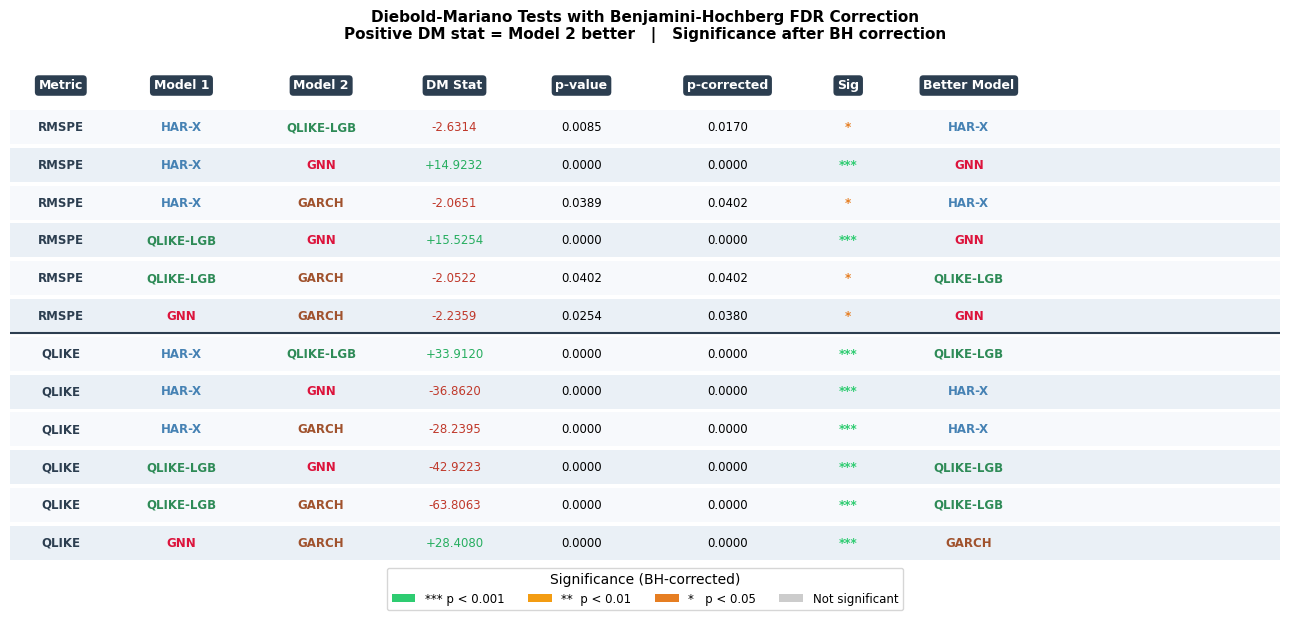

Saved: E:\Optiver\outputs\evaluation\dm_tests_table.png


In [22]:
# Cell: Plot BH-corrected DM test results as a formatted table figure
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path


EVAL_DIR = Path(r"E:\Optiver\outputs\evaluation")
dm_df    = pd.read_csv(EVAL_DIR / "dm_tests_all_models_corrected.csv")

def sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

# ── Build display dataframe ───────────────────────────────────────────────────
rows = []
for _, row in dm_df.iterrows():
    rows.append({
        "Metric":       row["metric"],
        "Model 1":      row["model_1"],
        "Model 2":      row["model_2"],
        "DM Stat":      f"{row['dm_stat']:+.4f}",
        "p-value":      f"{row['p_value']:.4f}",
        "p-corrected":  f"{row['p_value_corrected']:.4f}",
        "Sig":          sig_stars(row["p_value_corrected"]),
        "Better Model": row["model_2"] if row["dm_stat"] > 0 else row["model_1"],
    })
display_df = pd.DataFrame(rows)

# ── Colour mapping ────────────────────────────────────────────────────────────
model_colors = {
    "HAR-X":     "steelblue",
    "QLIKE-LGB": "seagreen",
    "GNN":       "crimson",
    "GARCH":     "sienna",
}
sig_colors = {
    "***": "#2ecc71",
    "**":  "#f39c12",
    "*":   "#e67e22",
    "":    "#cccccc",
}
metric_bg = {
    "RMSPE": "#1e2a3a",
    "QLIKE": "#1a2e1a",
}

# ── Plot ──────────────────────────────────────────────────────────────────────
col_labels  = ["Metric", "Model 1", "Model 2", "DM Stat",
               "p-value", "p-corrected", "Sig", "Better Model"]
n_rows      = len(display_df)
n_cols      = len(col_labels)
col_widths  = [0.08, 0.11, 0.11, 0.10, 0.10, 0.13, 0.06, 0.13]

fig_height  = 0.45 * (n_rows + 1.5)
fig, ax     = plt.subplots(figsize=(13, fig_height))
ax.axis("off")

fig.patch.set_facecolor("white")
fig.suptitle(
    "Diebold-Mariano Tests with Benjamini-Hochberg FDR Correction\n"
    "Positive DM stat = Model 2 better   |   Significance after BH correction",
    fontsize=11, fontweight="bold", y=1.01
)

# Header
header_y = 1.0
x_cursor = 0.0
for j, (label, w) in enumerate(zip(col_labels, col_widths)):
    ax.text(x_cursor + w / 2, header_y, label,
            ha="center", va="center", fontsize=9,
            fontweight="bold", color="white",
            transform=ax.transAxes,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#2c3e50", edgecolor="none"))
    x_cursor += w

# Rows
row_height = 1.0 / (n_rows + 1)
for i, (_, row) in enumerate(display_df.iterrows()):
    y = 1.0 - (i + 1) * row_height - row_height * 0.1
    bg = "#f7f9fc" if i % 2 == 0 else "#eaf0f6"

    # Row background
    ax.add_patch(mpatches.FancyBboxPatch(
        (0, y - row_height * 0.45), 1, row_height * 0.9,
        boxstyle="square,pad=0",
        facecolor=bg, edgecolor="none",
        transform=ax.transAxes, zorder=0,
    ))

    x_cursor = 0.0
    for j, (col, w) in enumerate(zip(col_labels, col_widths)):
        val   = row[col]
        color = "black"
        fw    = "normal"

        if col == "Metric":
            color = "#2c3e50"
            fw    = "bold"
        elif col in ("Model 1", "Model 2"):
            color = model_colors.get(val, "black")
            fw    = "bold"
        elif col == "Sig":
            color = sig_colors.get(val, "black")
            fw    = "bold"
        elif col == "Better Model":
            color = model_colors.get(val, "black")
            fw    = "bold"
        elif col == "DM Stat":
            color = "#27ae60" if row["DM Stat"].startswith("+") else "#c0392b"

        ax.text(x_cursor + w / 2, y, val,
                ha="center", va="center",
                fontsize=8.5, color=color, fontweight=fw,
                transform=ax.transAxes)
        x_cursor += w

# Divider line between RMSPE and QLIKE blocks
divider_y = 1.0 - 6 * row_height - row_height * 0.55
line = Line2D([0, 1], [divider_y, divider_y],
              transform=ax.transAxes,
              color="#2c3e50", linewidth=1.5, zorder=5)
ax.add_artist(line)

# Legend
legend_elements = [
    mpatches.Patch(facecolor=sig_colors["***"], label="*** p < 0.001"),
    mpatches.Patch(facecolor=sig_colors["**"],  label="**  p < 0.01"),
    mpatches.Patch(facecolor=sig_colors["*"],   label="*   p < 0.05"),
    mpatches.Patch(facecolor=sig_colors[""],    label="Not significant"),
]
ax.legend(handles=legend_elements, loc="lower center",
          bbox_to_anchor=(0.5, -0.08), ncol=4,
          fontsize=8.5, framealpha=0.8, title="Significance (BH-corrected)")

plt.tight_layout()
out = EVAL_DIR / "dm_tests_table.png"
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {out}")